In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from src.deep_learning.preprocessing import scale_df, TimeSeriesDataset
from src.deep_learning.lstm_model import LSTMModel
from src.deep_learning.training import  evaluate_model, train_model
from src.deep_learning.forecast_evaluation import run_forecast_and_plot
import joblib

In [2]:
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
train_df = pd.read_parquet(r"..\data\processed\train.parquet")
val_df = pd.read_parquet(r"..\data\processed\val.parquet")
test_df = pd.read_parquet(r"..\data\processed\test.parquet")
consumption_df = pd.read_parquet(r"..\data\processed\consumption_fe.parquet")

In [4]:
train_df.head()

,date,consumption,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2018-01-01 00:00:00,27412.81,0.000000,1.000000,0.0,1.0,0.5,0.866025
1,2018-01-01 01:00:00,26324.39,0.258819,0.965926,0.0,1.0,0.5,0.866025
2,2018-01-01 02:00:00,24635.32,0.500000,0.866025,0.0,1.0,0.5,0.866025
3,2018-01-01 03:00:00,23872.12,0.707107,0.707107,0.0,1.0,0.5,0.866025
4,2018-01-01 04:00:00,23194.89,0.866025,0.500000,0.0,1.0,0.5,0.866025


In [5]:
feature_cols = ["consumption",
    "hour_sin", "hour_cos",
    "day_sin", "day_cos",
    "month_sin", "month_cos"
]

target = "consumption"

scale_cols = ["consumption"]

In [6]:
scaler_path = r"..\models\scaler_ft.pkl"
scaler = joblib.load(scaler_path)

train_scaled = scale_df(df=train_df, train=True, scaler=scaler, scale_cols=scale_cols)

val_scaled = scale_df(df=val_df, train=False, scaler=scaler, scale_cols=scale_cols)

test_scaled = scale_df(df=test_df, train=False, scaler=scaler, scale_cols=scale_cols)

In [7]:
window_size = 168
horizon = 24

hidden_size = 224
num_layers = 2
lin_features = 32
dropout = 0.17498226896177801

lr= 0.0006477616087737383
num_epochs = 50
min_delta = 0.0001
patience = 7
scheduler_patience = 3
weight_decay = 3.680266245751368e-06

In [8]:
train_dataset = TimeSeriesDataset(df=train_scaled, feature_cols=feature_cols, target_col=target, window_size=window_size, horizon=horizon) 
val_dataset = TimeSeriesDataset(df=val_scaled, feature_cols=feature_cols, target_col=target, window_size=window_size, horizon=horizon) 
test_dataset = TimeSeriesDataset(df=test_scaled, feature_cols=feature_cols, target_col=target, window_size=window_size, horizon=horizon) 

In [9]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_size=len(feature_cols),
                    hidden_size=hidden_size,
                    num_layers=num_layers,
                    horizon=horizon,
                    lin_features=lin_features,
                    dropout=dropout
                    )
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.HuberLoss()

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                            mode="min",
                                                            factor=0.5,
                                                            patience=scheduler_patience,
                                                            threshold=min_delta
                                                            )
model = model.to(device)

In [11]:
training_dict = {"model": model,
                "device": device,
                "train_loader":train_loader,
                "val_loader":val_loader,
                "criterion": criterion,
                "optimizer":optimizer,
                "lr_scheduler": lr_scheduler,
                "num_epochs": num_epochs,
                "save_path":r"..\models\best_model.pth",
                "min_delta":min_delta,
                "patience":patience
                }

In [12]:
train_total_loss, val_total_loss = train_model(**training_dict)

Epoch [001/050]
Train Loss: 0.046018 | Validation Loss: 0.034879 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [002/050]
Train Loss: 0.021925 | Validation Loss: 0.030623 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [003/050]
Train Loss: 0.017937 | Validation Loss: 0.026277 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [004/050]
Train Loss: 0.015765 | Validation Loss: 0.024944 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [005/050]
Train Loss: 0.014145 | Validation Loss: 0.022782 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [006/050]
Train Loss: 0.013022 | Validation Loss: 0.020715 | Learning Rate: 0.0006477616087737383
--> Validation loss improved. Saving model...
Epoch [007/050]
Train Loss: 0.011655 | Validation Loss: 0.023133 | Learning Rate: 0.0006477616087737

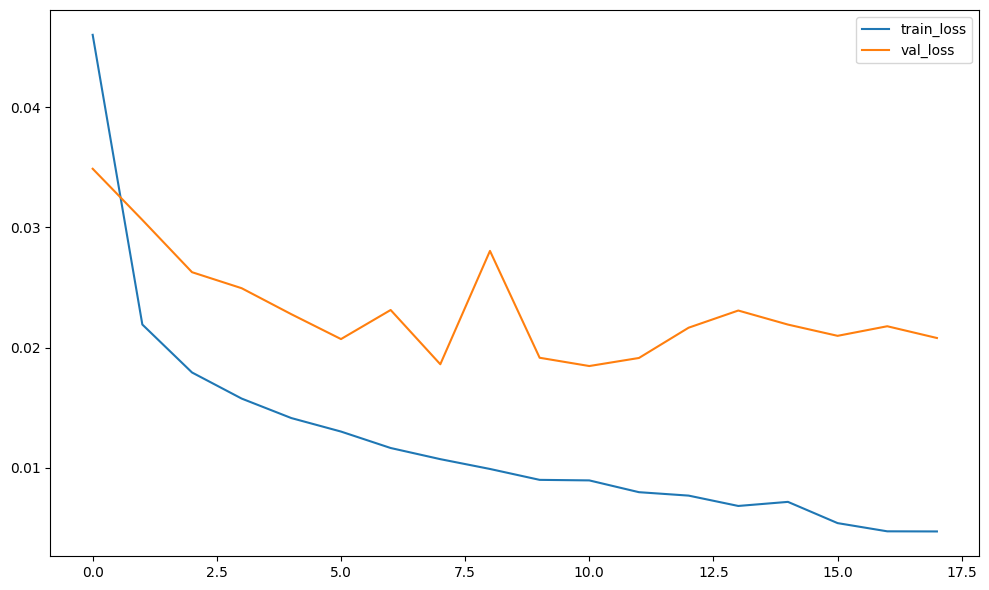

In [13]:
plt.figure(figsize=(10,6))
plt.plot(train_total_loss, label="train_loss")
plt.plot(val_total_loss, label="val_loss")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
model_path = training_dict["save_path"]
model.load_state_dict(torch.load(model_path, map_location=device))
test_loss, test_preds, test_targets = evaluate_model(model=model, 
                                                        device=device,
                                                        dataloader=test_loader,
                                                        criterion=criterion)

test_preds = torch.cat(test_preds, dim=0)
test_targets = torch.cat(test_targets, dim=0)

In [15]:
test_targets_np = test_targets.cpu().numpy()
test_preds_np = test_preds.cpu().numpy()

test_targets_inv = scaler.inverse_transform(test_targets_np.reshape(-1, 1)).reshape(test_targets_np.shape)
test_preds_inv = scaler.inverse_transform(test_preds_np.reshape(-1, 1)).reshape(test_preds_np.shape)

rmse = np.sqrt(mean_squared_error(test_targets_inv, test_preds_inv))
mae = mean_absolute_error(test_targets_inv, test_preds_inv)
r2 = r2_score(test_targets_inv, test_preds_inv)
print(f"Test Loss: {test_loss:.6f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2: {r2:.4f}")

Test Loss: 0.029969
RMSE: 1416.8946
MAE:  943.3586
R2: 0.9538


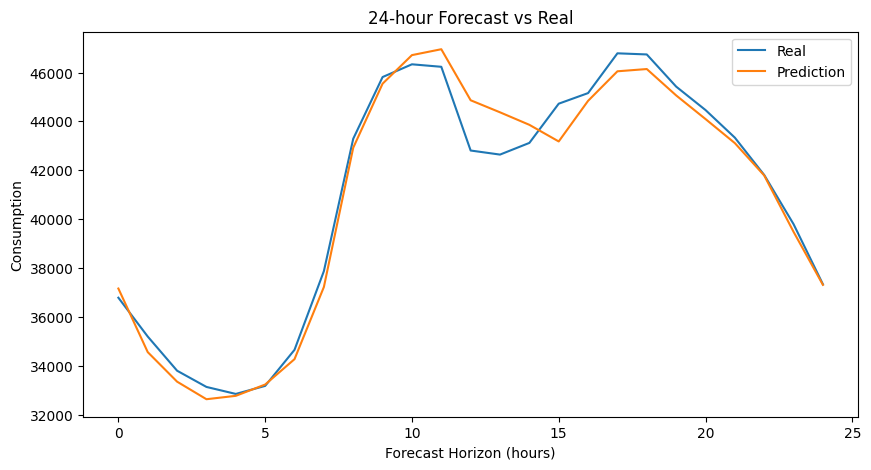

In [16]:
sample_idx = 25

plt.figure(figsize=(10, 5))
plt.plot(test_targets_inv[:sample_idx, 0], label="Real")
plt.plot(test_preds_inv[:sample_idx, 0], label="Prediction")
plt.title("24-hour Forecast vs Real")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Consumption")
plt.legend()
plt.show()

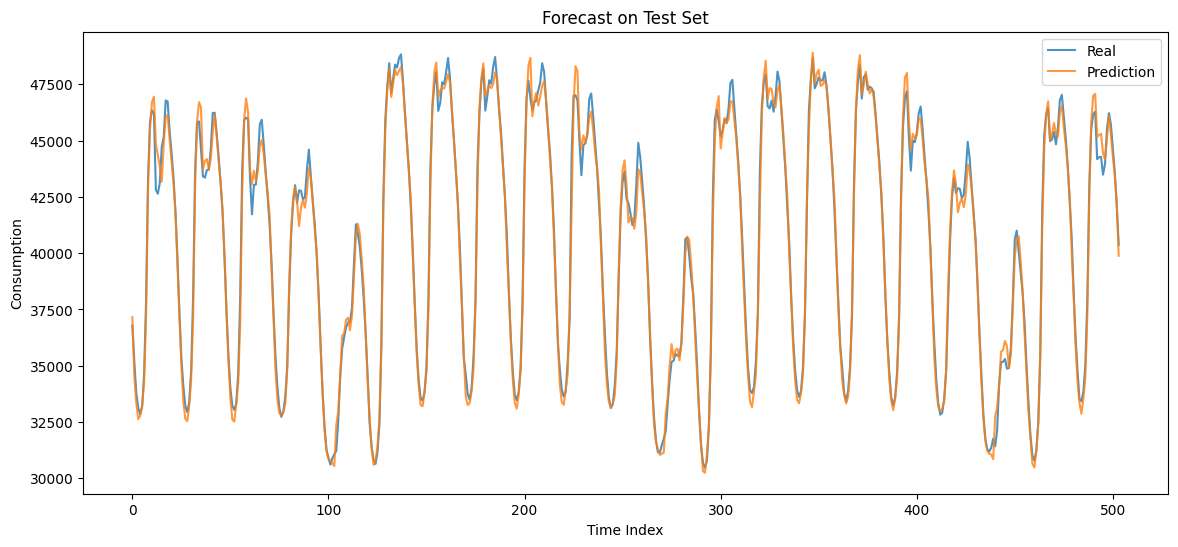

In [17]:
real_series = test_targets_inv[:168*3, 0]
pred_series = test_preds_inv[:168*3, 0]

plt.figure(figsize=(14, 6))
plt.plot(real_series, label="Real", alpha=0.8)
plt.plot(pred_series, label="Prediction", alpha=0.8)
plt.title("Forecast on Test Set")
plt.xlabel("Time Index")
plt.ylabel("Consumption")
plt.legend()
plt.show()

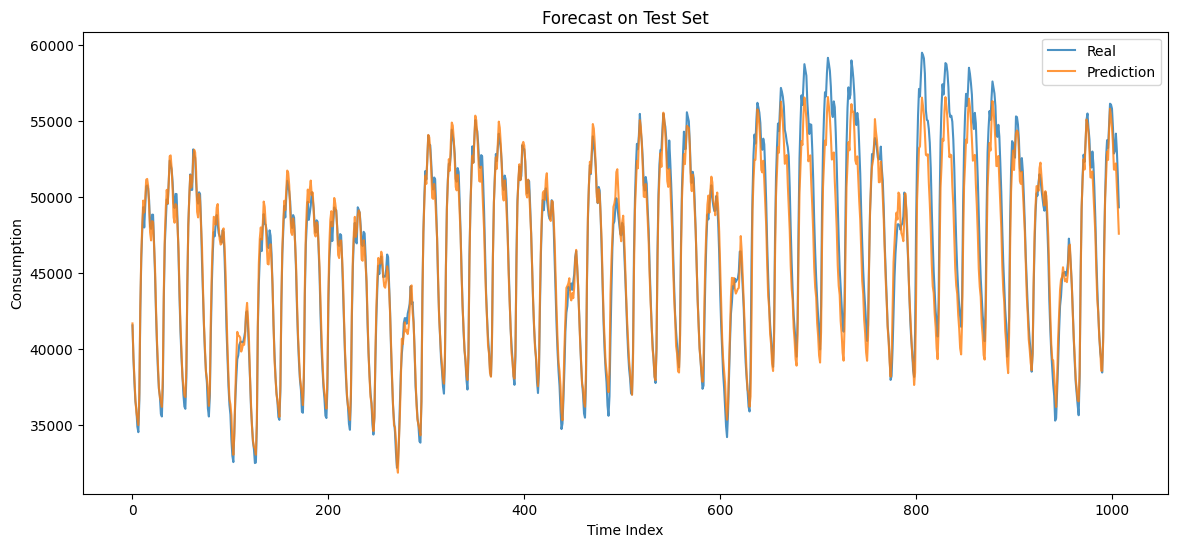

In [18]:
real_series = test_targets_inv[168*24:168*30, 0]
pred_series = test_preds_inv[168*24:168*30, 0]

plt.figure(figsize=(14, 6))
plt.plot(real_series, label="Real", alpha=0.8)
plt.plot(pred_series, label="Prediction", alpha=0.8)
plt.title("Forecast on Test Set")
plt.xlabel("Time Index")
plt.ylabel("Consumption")
plt.legend()
plt.show()

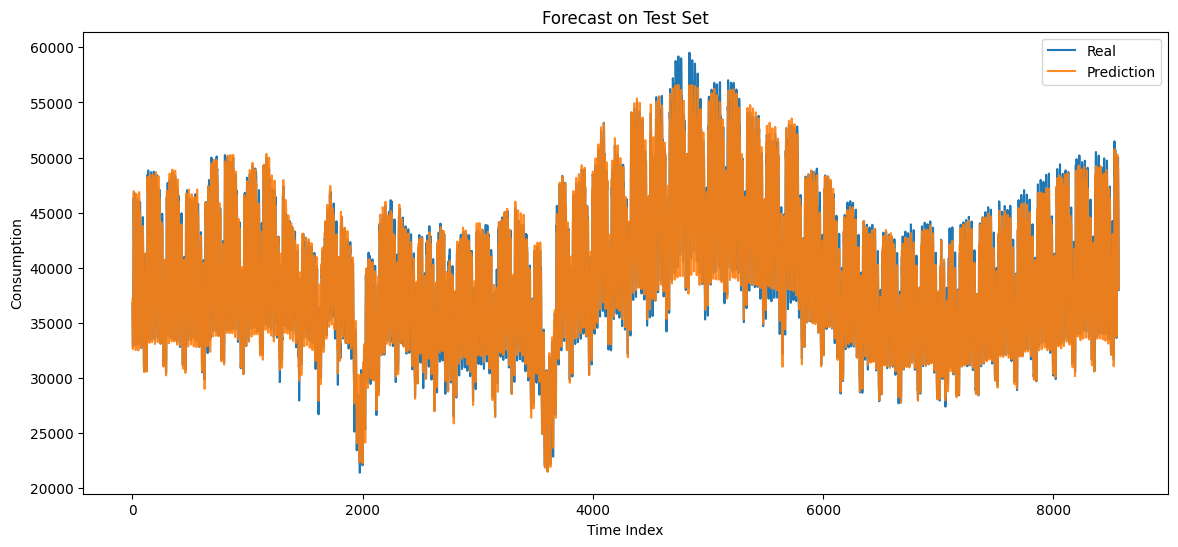

In [19]:
real_series = test_targets_inv[:, 0]
pred_series = test_preds_inv[:, 0]

plt.figure(figsize=(14, 6))
plt.plot(real_series, label="Real", alpha=1)
plt.plot(pred_series, label="Prediction", alpha=0.9)
plt.title("Forecast on Test Set")
plt.xlabel("Time Index")
plt.ylabel("Consumption")
plt.legend()
plt.show()

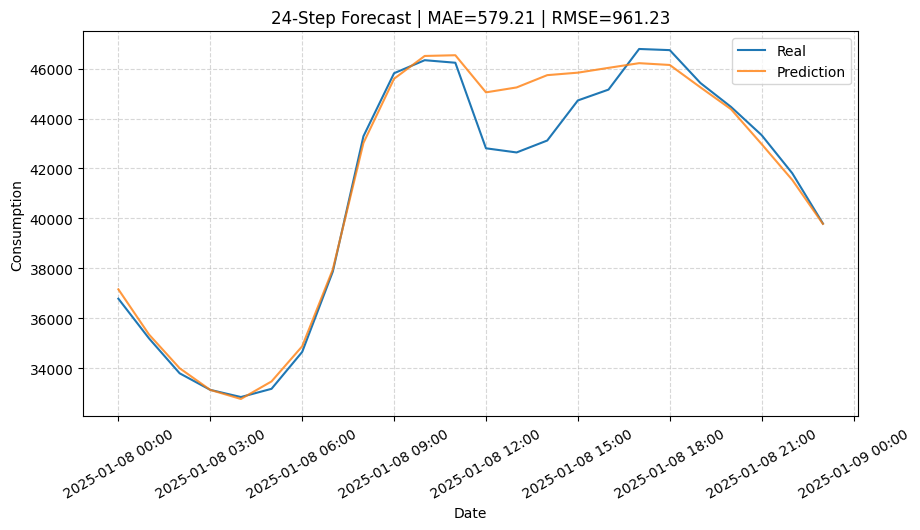

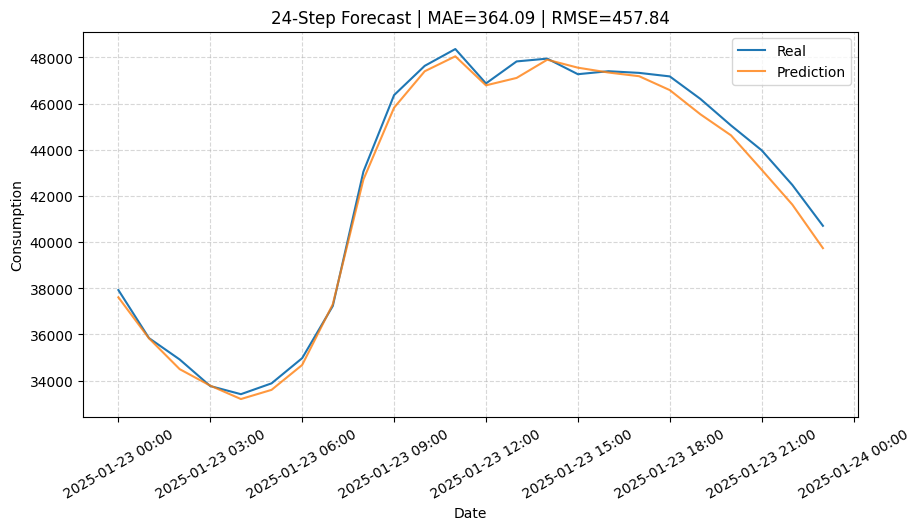

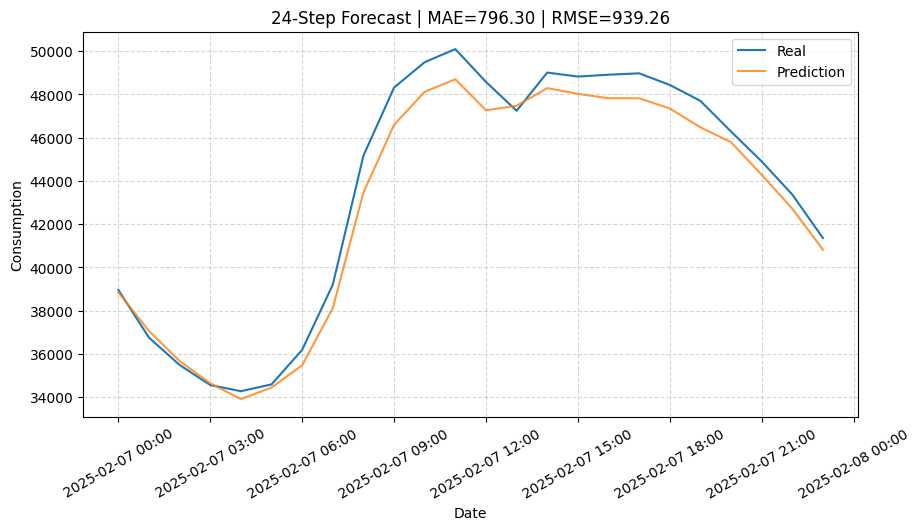

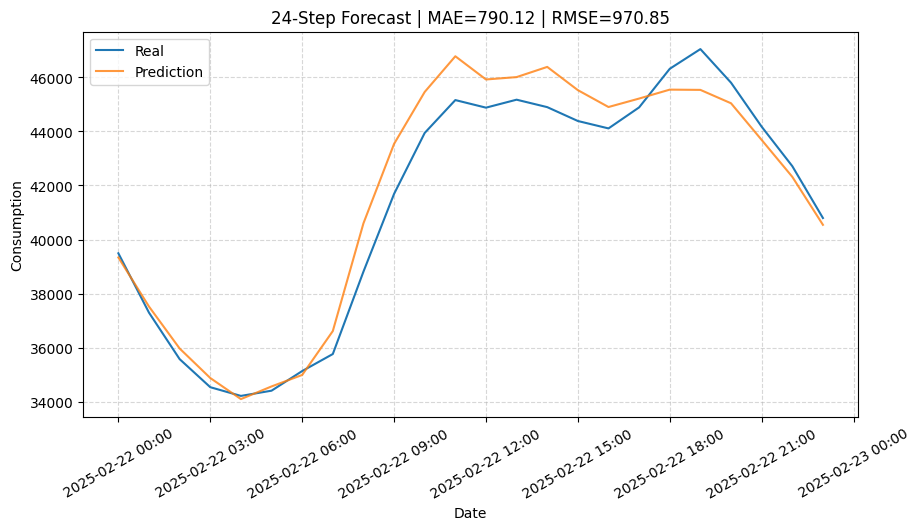

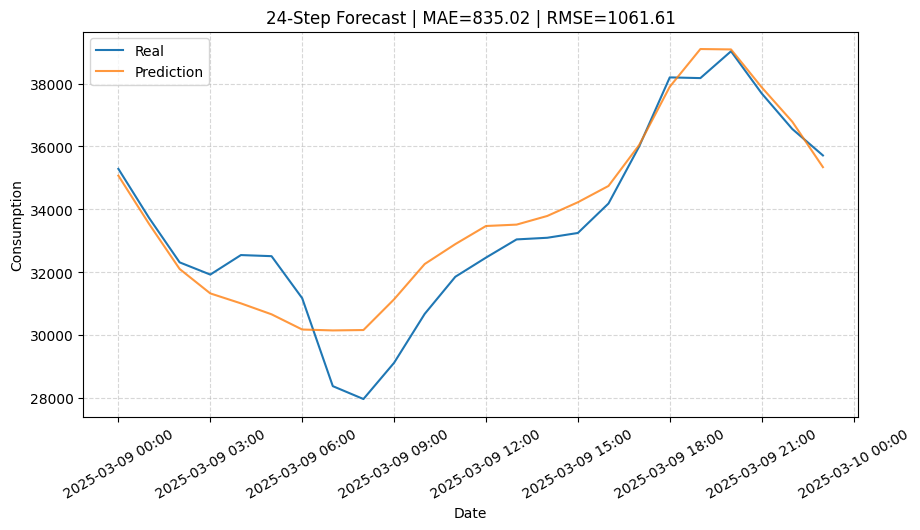

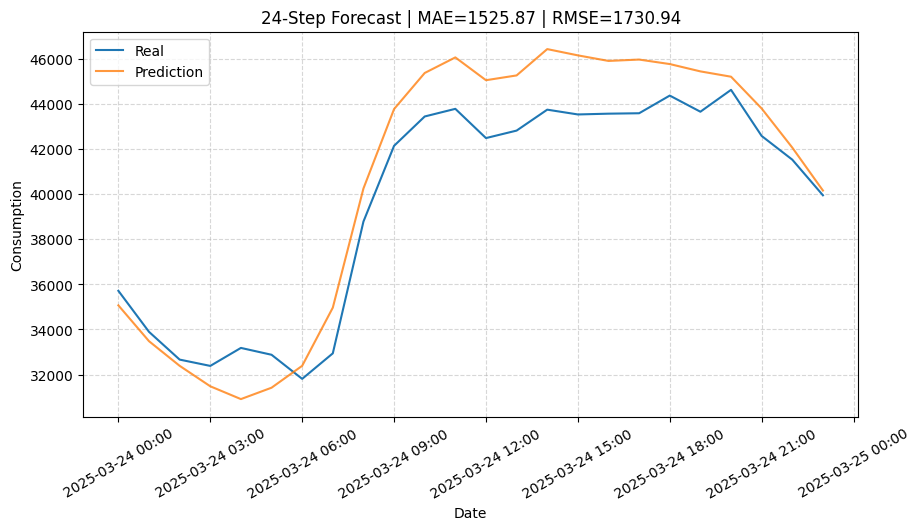

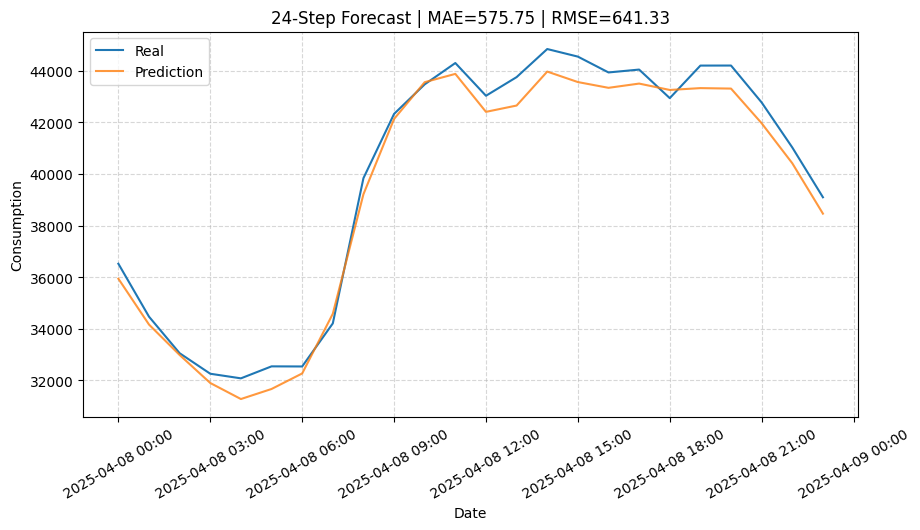

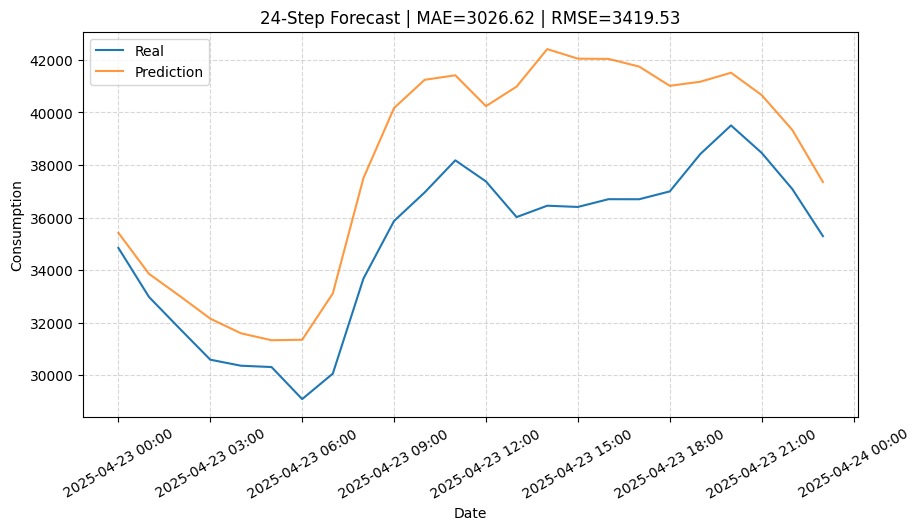

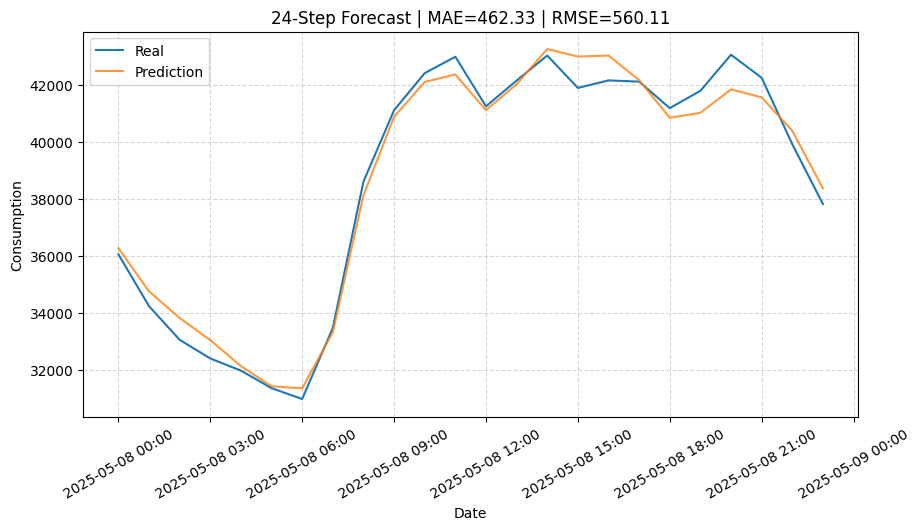

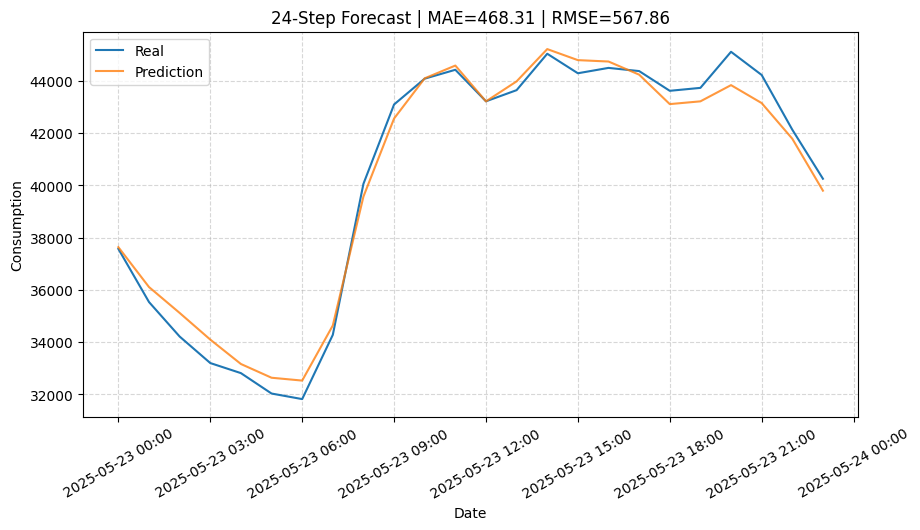

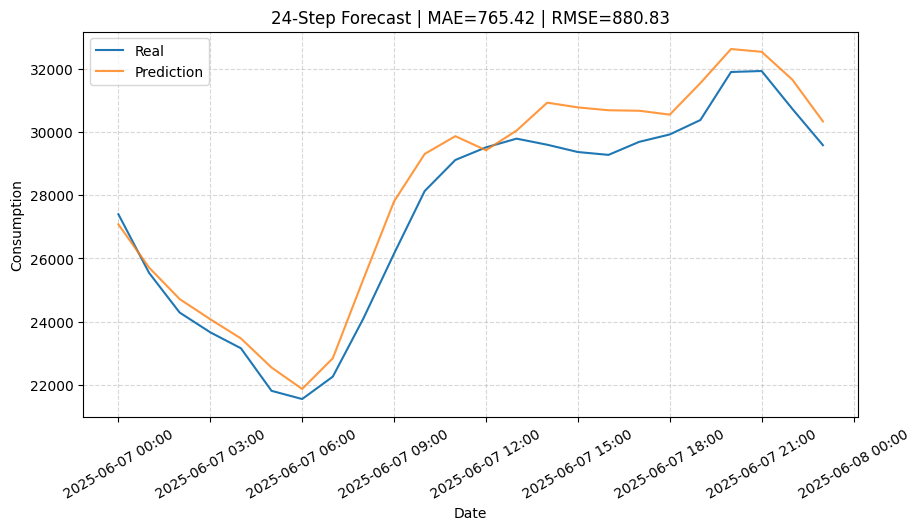

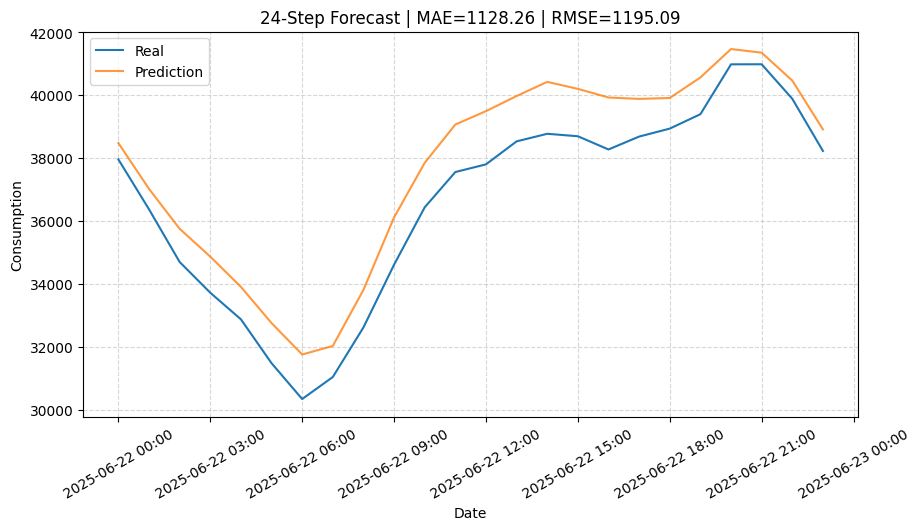

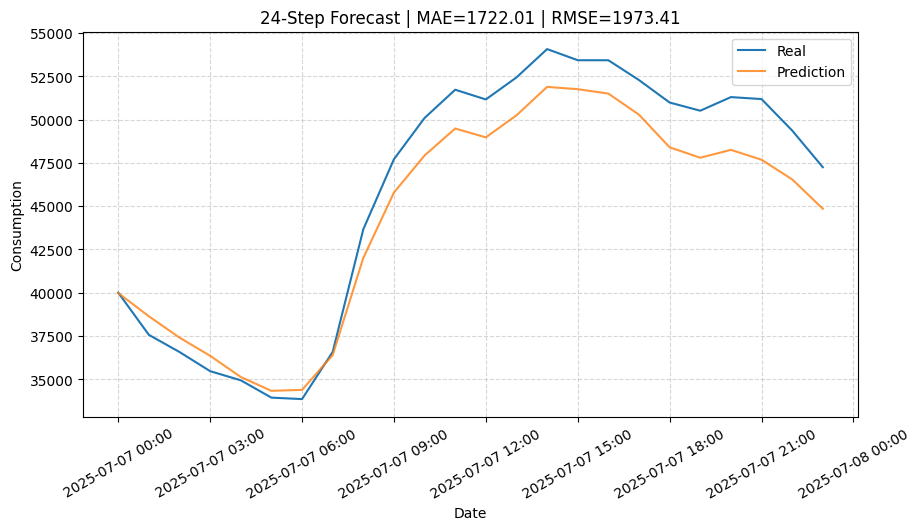

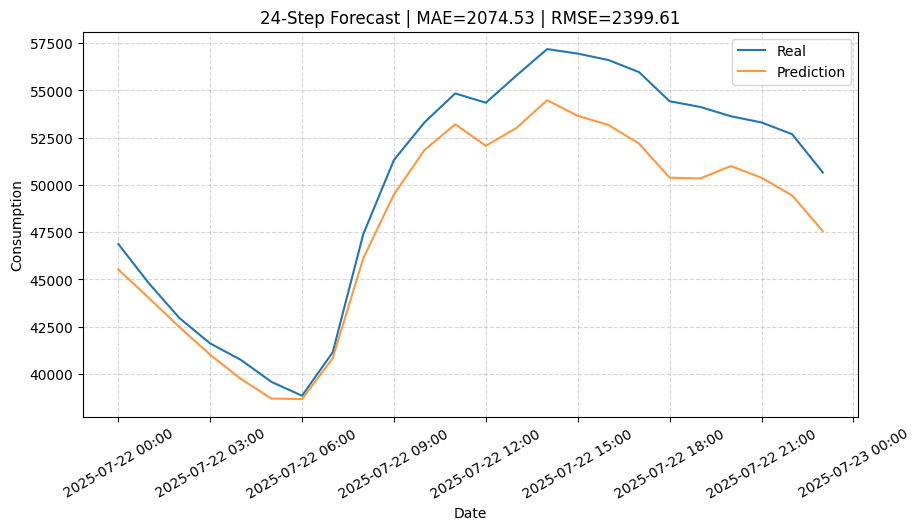

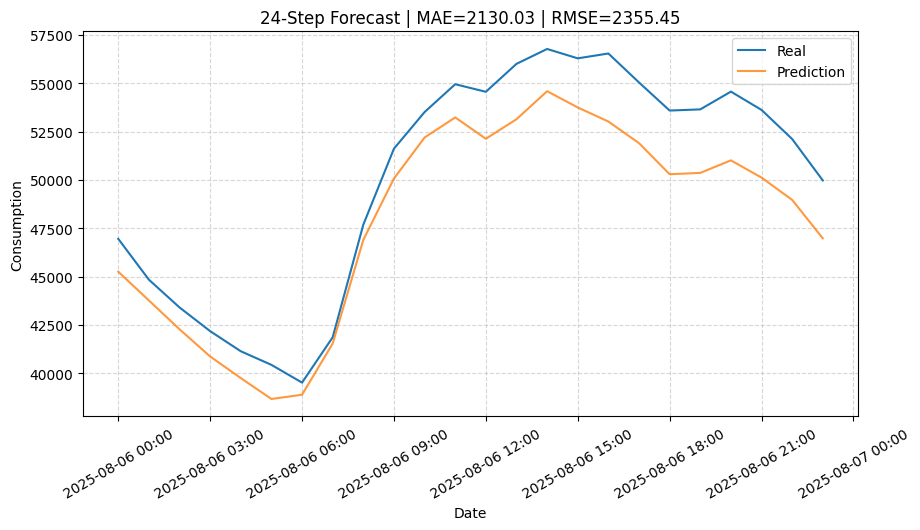

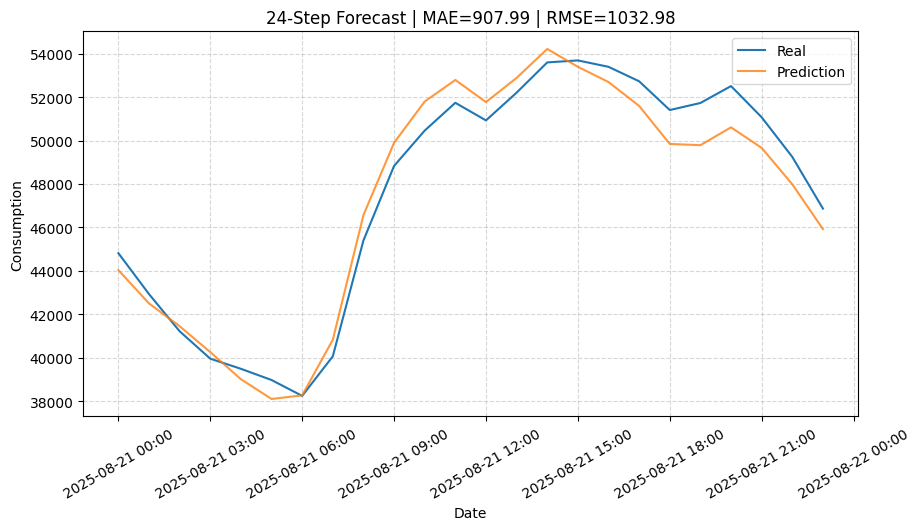

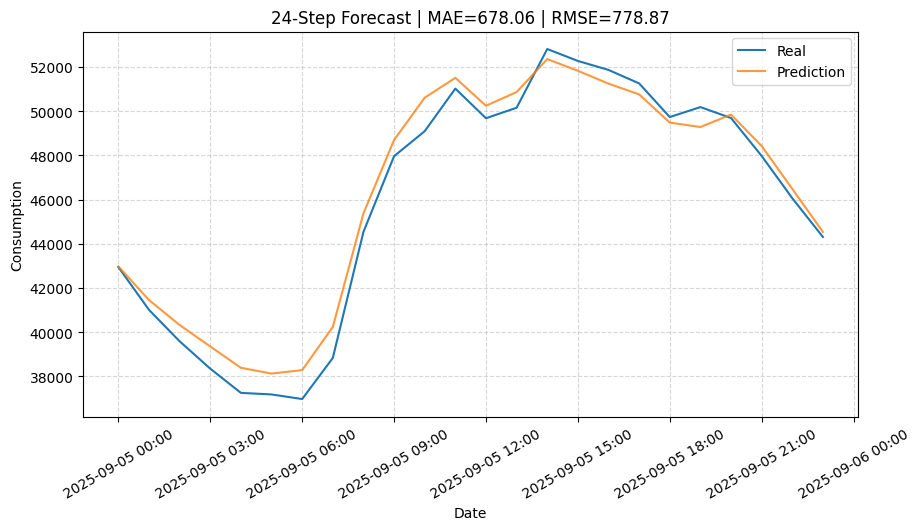

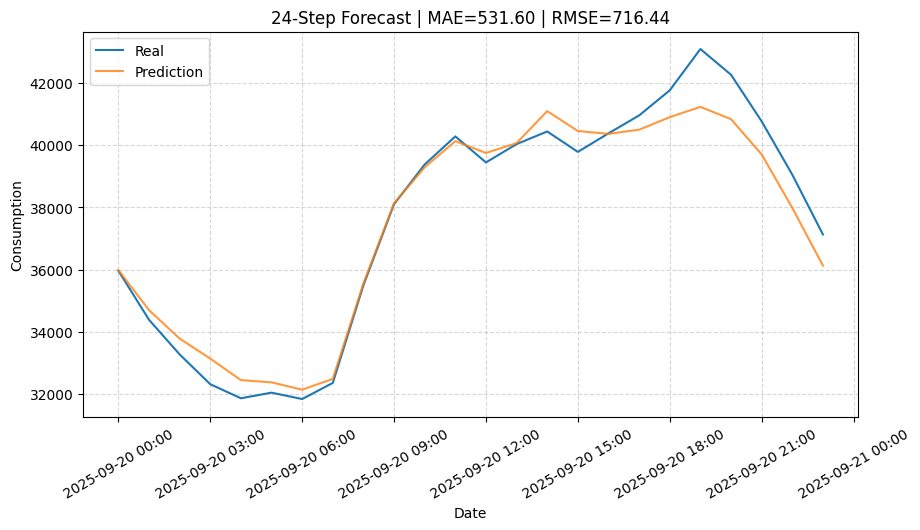

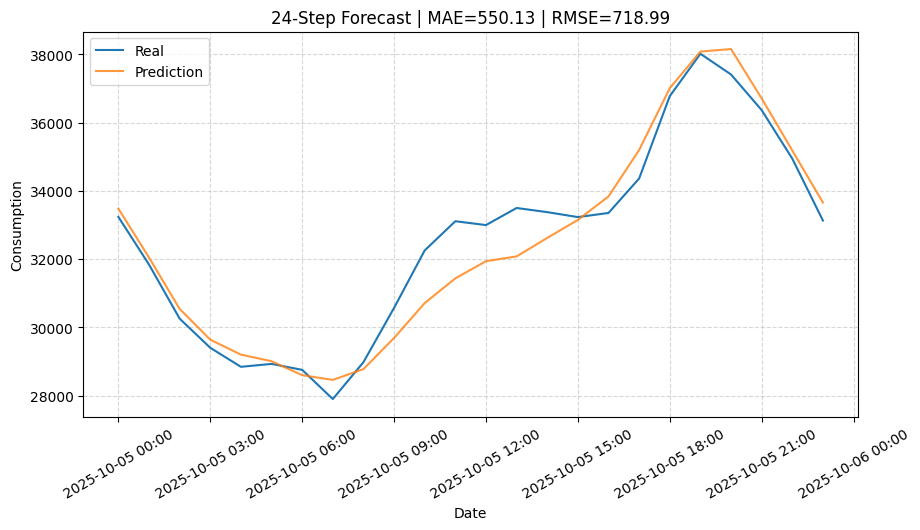

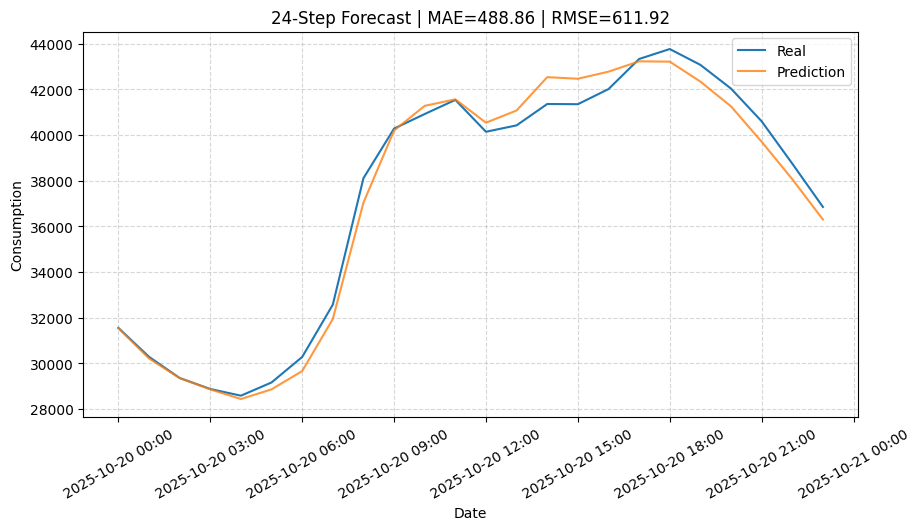

In [20]:
all_metrics = []

for d in range(0,300,15):
    metrics = run_forecast_and_plot(
        model=model, device=device, df=test_df, scaled_df=test_scaled,
        feature_cols=feature_cols, scaler=scaler,
        day=d,
        window_size=window_size,
        horizon=horizon
    )
    all_metrics.append(metrics)